In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
products=pd.read_csv(r'C:\Users\namaz\OneDrive\Documents\products.csv')
categories=pd.read_csv(r'C:\Users\namaz\OneDrive\sistem\categories.csv')
merged= pd.merge(products, categories, on='category_id')    
merged   
    



,product_id,product_name,brand_id,category_id,model_year,list_price,category_name
0,1,Trek 820 - 2016,9,6,2016,379.99,Mountain Bikes
1,2,Ritchey Timberwolf Frameset - 2016,5,6,2016,749.99,Mountain Bikes
2,3,Surly Wednesday Frameset - 2016,8,6,2016,999.99,Mountain Bikes
3,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99,Mountain Bikes
4,5,Heller Shagamaw Frame - 2016,3,6,2016,1320.99,Mountain Bikes
...,...,...,...,...,...,...,...
316,317,Trek Checkpoint ALR 5 - 2019,9,7,2019,1999.99,Road Bikes
317,318,Trek Checkpoint ALR 5 Women's - 2019,9,7,2019,1999.99,Road Bikes
318,319,Trek Checkpoint SL 5 Women's - 2019,9,7,2019,2799.99,Road Bikes
319,320,Trek Checkpoint SL 6 - 2019,9,7,2019,3799.99,Road Bikes


C:\Users\namaz\AppData\Local\Temp\ipykernel_24296\4167079537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category_name', y='list_price', data=avg_price, palette='Set2')


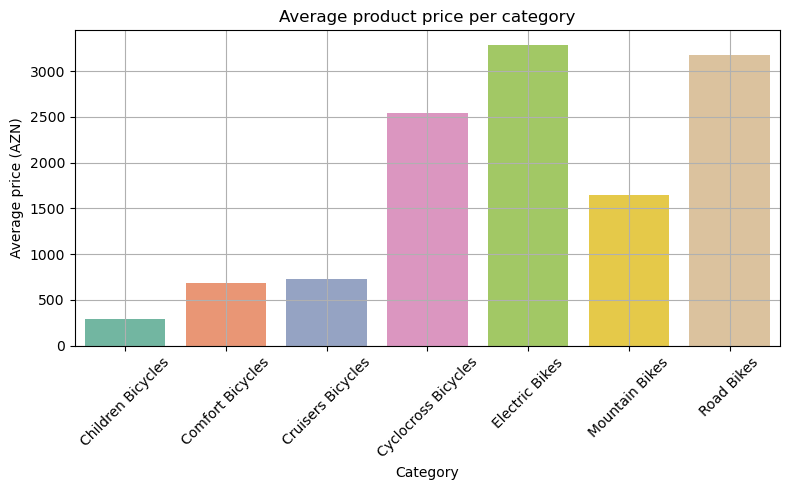

In [11]:

avg_price = merged.groupby('category_name')['list_price'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='category_name', y='list_price', data=avg_price, palette='Set2')

plt.title('Average product price per category')
plt.xlabel('Category')
plt.ylabel('Average price (AZN)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()  
plt.show()    

C:\Users\namaz\AppData\Local\Temp\ipykernel_24296\82661089.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='brand_name', y='list_price', data=avg_prices, palette='Set3')


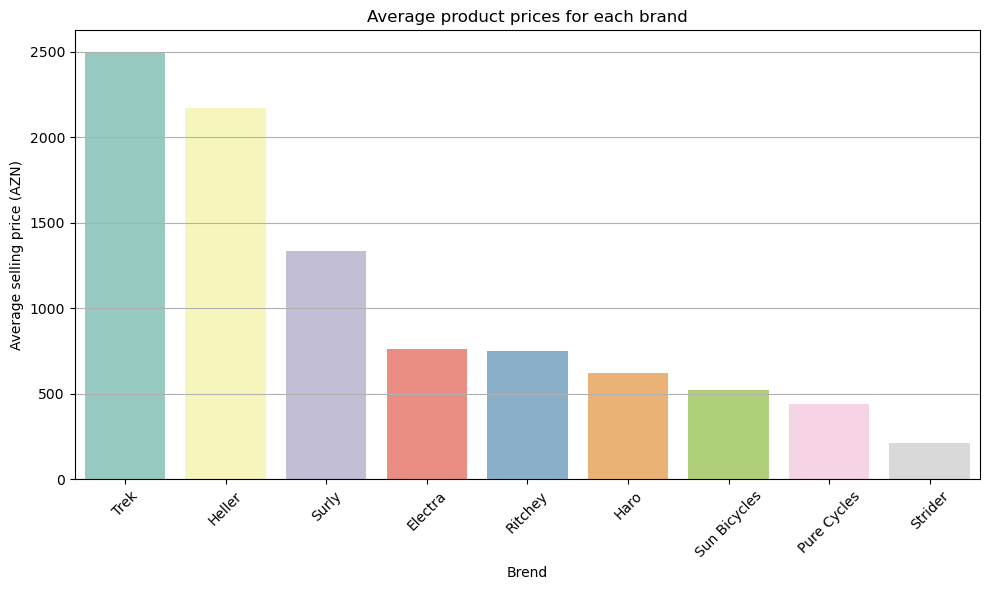

In [13]:
brands = pd.read_csv( r'C:\Users\namaz\OneDrive\brands.csv') 
df = pd.merge(products, brands, on='brand_id')
avg_prices = df.groupby('brand_name')['list_price'].mean().reset_index()
avg_prices = avg_prices.sort_values(by='list_price', ascending=False)  # Böyüklər yuxarı olsun
plt.figure(figsize=(10,6))
sns.barplot(x='brand_name', y='list_price', data=avg_prices, palette='Set3')

plt.title('Average product prices for each brand')
plt.xlabel('Brend')
plt.ylabel('Average selling price (AZN)') 
plt.xticks(rotation=45)
plt.grid(axis='y') 
plt.tight_layout()
plt.show()   


In [15]:
filtered = df[df['brand_name'].isin(['Santa Cruz Bikes', 'Baldwinn Bikes'])]
from scipy.stats import ttest_ind

# Separate the prices of two brands
santa_prices = filtered[filtered['brand_name'] == 'Santa Cruz Bikes']['list_price']
baldwinn_prices = filtered[filtered['brand_name'] == 'Baldwinn Bikes']['list_price']

t_stat, p_value = ttest_ind(santa_prices, baldwinn_prices, equal_var=False)  # Welch t-test

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}") 
alpha = 0.05 

if p_value < alpha:
    print("Conclusion: There is a statistically significant difference between the means (H₀ is rejected).") 
else:
    print("Conclusion: There is NO statistically significant difference between the means (H₀ is accepted).") 



T-statistic: nan
P-value: nan
Conclusion: There is NO statistically significant difference between the means (H₀ is accepted).


T-statistic: nan
P-value: nan
 Result: There is NO statistically significant difference between the means (H₀ is accepted).


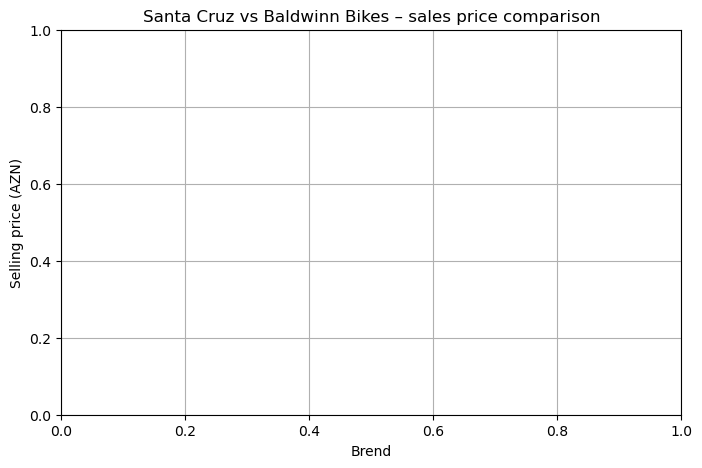

In [19]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
filtered = df[df['brand_name'].isin(['Santa Cruz Bikes', 'Baldwinn Bikes'])]
santa = filtered[filtered['brand_name'] == 'Santa Cruz Bikes']['list_price']
baldwinn = filtered[filtered['brand_name'] == 'Baldwinn Bikes']['list_price']
t_stat, p_value = ttest_ind(santa, baldwinn, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05

if p_value < alpha:
    print("Conclusion: There is a statistically significant difference between the means (H₀ is rejected).")
else:
    print(" Result: There is NO statistically significant difference between the means (H₀ is accepted).")
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='brand_name',
    y='list_price',
    data=filtered,   # LOOK HERE we use filtered, not df!
    palette='Set2'
)
plt.title('Santa Cruz vs Baldwinn Bikes – sales price comparison')
plt.xlabel('Brend')
plt.ylabel('Selling price (AZN)')
plt.grid(True)
plt.show()  





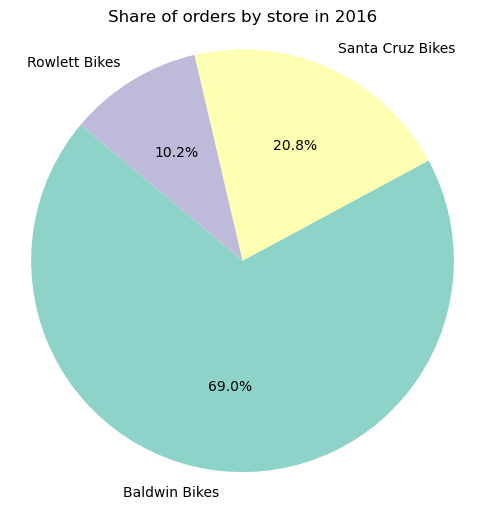

In [21]:
orders = pd.read_csv(r'C:\Users\namaz\OneDrive\orders.csv')
stores = pd.read_csv(r'C:\Users\namaz\OneDrive\stores.csv') 
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders_2016 = orders[orders['order_date'].dt.year == 2016]
store_counts = orders_2016['store_id'].value_counts().reset_index()
store_counts.columns = ['store_id', 'order_count']
storder = pd.merge(store_counts, stores, on='store_id')
plt.figure(figsize=(6, 6))
plt.pie(
    storder['order_count'],
    labels=storder['store_name'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors
)

plt.title('Share of orders by store in 2016')
plt.axis('equal') # Make it look circular
plt.show()   




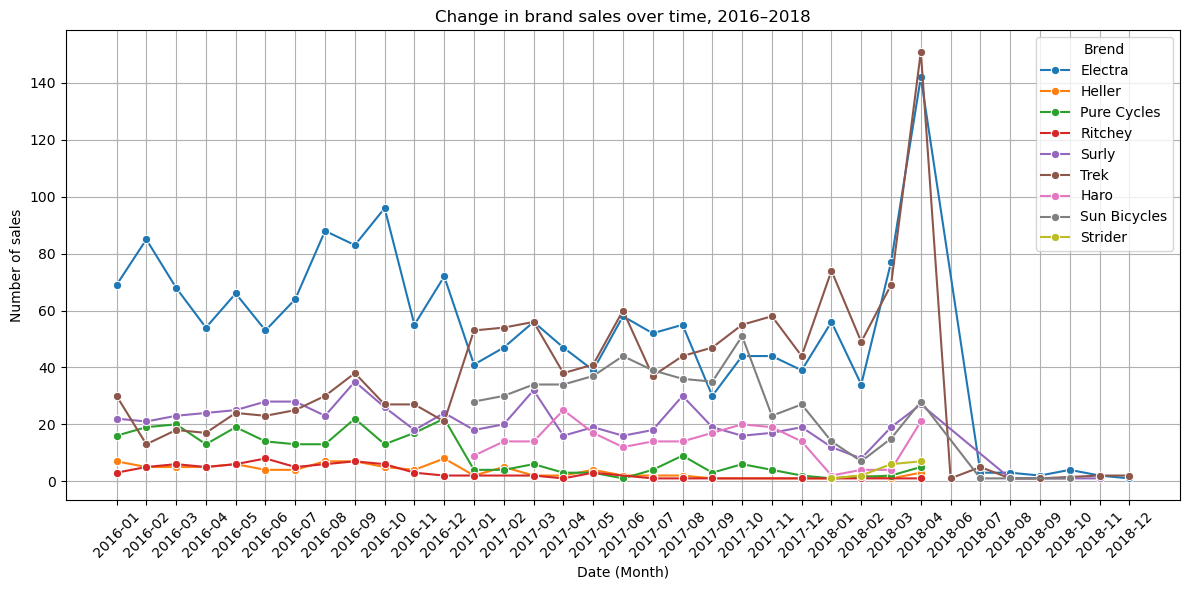

In [25]:
order_items = pd.read_csv(r'C:\Users\namaz\OneDrive\order_items.csv') 
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders_filtered = orders[(orders['order_date'].dt.year >= 2016) & (orders['order_date'].dt.year <= 2018)]
# order_items ilə orders birləşir
order_data = pd.merge(order_items, orders_filtered, on='order_id')

# sonra məhsul və brendlərlə birləşir
order_data = pd.merge(order_data, products, on='product_id')
order_data = pd.merge(order_data, brands, on='brand_id') 
order_data['year_month'] = order_data['order_date'].dt.to_period('M').astype(str) 

brand_sales = (
    order_data.groupby(['year_month', 'brand_name'])
    .size()
    .reset_index(name='sales_count')
)
plt.figure(figsize=(12, 6))
sns.lineplot(data=brand_sales, x='year_month', y='sales_count', hue='brand_name', marker='o')

plt.title('Change in brand sales over time, 2016–2018')
plt.xlabel('Date (Month)')
plt.ylabel('Number of sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Brend')
plt.show()   


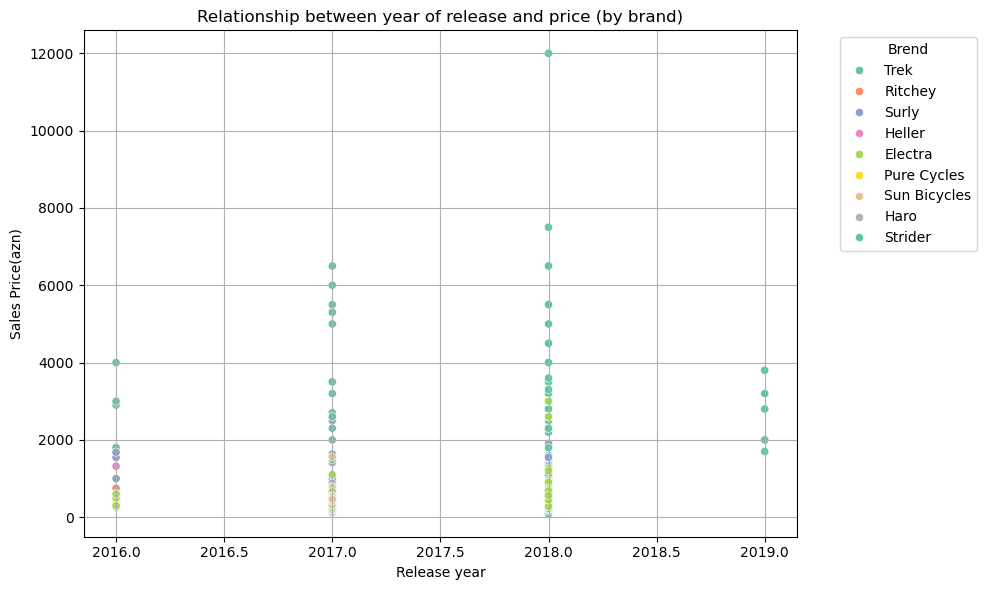

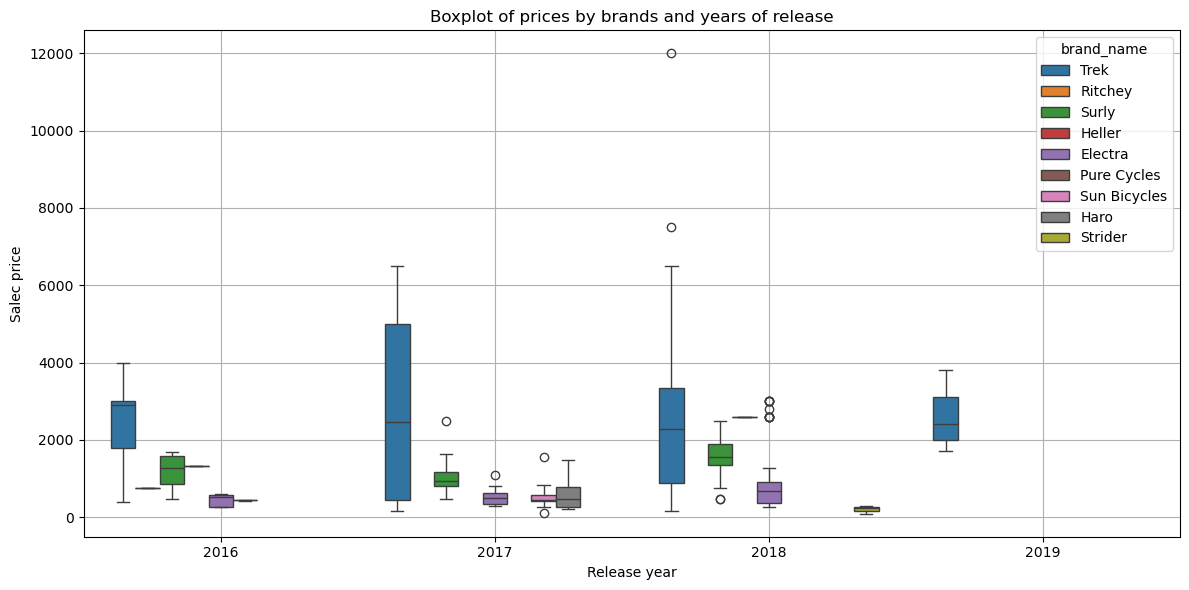

In [27]:
products = pd.read_csv(r'C:\Users\namaz\OneDrive\Documents\products.csv')
dff = pd.merge(products, brands, on='brand_id')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dff, x='model_year', y='list_price', hue='brand_name', palette='Set2')
plt.title('Relationship between year of release and price (by brand)')
plt.xlabel('Release year')
plt.ylabel('Sales Price(azn)')
plt.grid(True)
plt.legend(title='Brend', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()
correlation = df['model_year'].corr(df['list_price'])
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='model_year', y='list_price', hue='brand_name')
plt.title('Boxplot of prices by brands and years of release')
plt.xlabel('Release year')
plt.ylabel('Salec price')
plt.grid(True)
plt.tight_layout() 
plt.show() 
 
